**Handling FITS File**

In [61]:
#Importing Necessary Libraries And Modules
import numpy as np,math
from astropy.io import fits
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from astropy.stats import sigma_clipped_stats
from photutils.detection import DAOStarFinder
from photutils.aperture import CircularAperture,CircularAnnulus,ApertureStats,aperture_photometry
from acstools import acszpt

In [50]:
fits_file=fits.open('ngc1261.fits')
print(fits_file)

In [51]:
img_data=fits_file[0].data
print(img_data)

[[-25. -25. -25. ... -25. -25. -25.]
 [-25. -25. -25. ... -25. -25. -25.]
 [-25. -25. -25. ... -25. -25. -25.]
 ...
 [-25. -25. -25. ... -25. -25. -25.]
 [-25. -25. -25. ... -25. -25. -25.]
 [-25. -25. -25. ... -25. -25. -25.]]


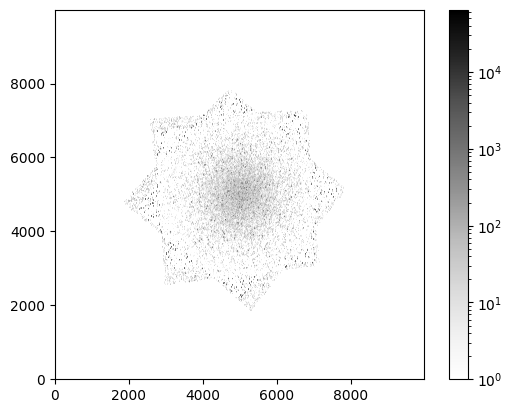

In [52]:
plt.figure()
plt.imshow(img_data,origin='lower',norm=LogNorm(),cmap='Greys')
plt.colorbar()
plt.show()

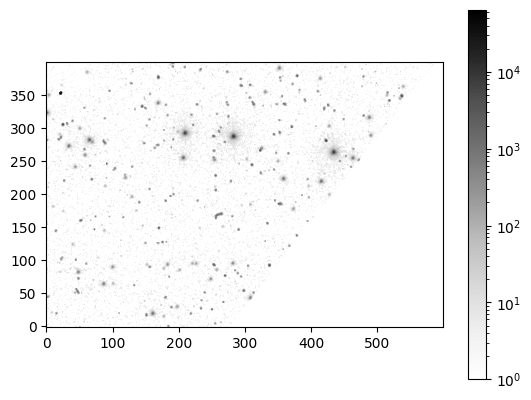

In [53]:
sec1=img_data[2250:2650,5350:5950]
plt.figure()
plt.imshow(sec1,origin='lower',norm=LogNorm(),cmap='Greys')
plt.colorbar()
plt.show()

In [54]:
mean,median,std=sigma_clipped_stats(sec1,sigma=3.0)
print((mean,median,std))

(np.float32(0.11206129), np.float32(0.0), np.float32(2.3509839))


In [55]:
daofind=DAOStarFinder(fwhm=3.0,threshold=5.0*std) #Full Width Half Maximum
src=daofind(sec1-median)
for i in src.colnames:
    if i not in ('id','npix'):
        src[i].info.format='%.2f'
src.pprint(max_width=76)

 id xcentroid ycentroid sharpness ...  peak    flux   mag  daofind_mag
--- --------- --------- --------- ... ------ ------- ----- -----------
  1     50.45     -0.00      0.90 ... 119.00  230.00 -5.90       -2.27
  2    184.42      1.07      0.91 ... 670.00 1643.00 -8.04       -4.09
  3    244.83      3.47      0.97 ...  20.00   56.00 -4.37       -0.25
  4    255.20      5.07      0.97 ... 560.00 1236.00 -7.73       -3.85
  5    279.23      5.22      0.94 ...  21.00   43.00 -4.08       -0.35
  6     62.12      6.07      0.98 ...  17.00   -3.00   nan       -0.19
  7    264.01      6.61      0.81 ... 113.00  277.00 -6.11       -2.28
  8     42.87      7.26      0.79 ...  28.00   53.00 -4.31       -0.80
  9     57.26      7.94      0.86 ...  31.00   74.00 -4.67       -0.79
 10     59.79     11.84      0.82 ...  17.00   45.00 -4.13       -0.27
...       ...       ...       ... ...    ...     ...   ...         ...
462    184.88    390.48      0.92 ...  19.00   40.00 -4.01       -0.20
463   

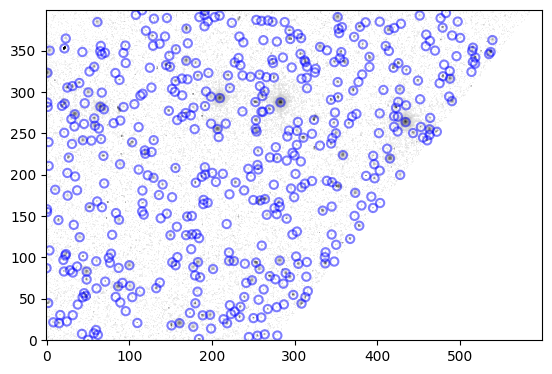

In [56]:
pos=np.transpose((src['xcentroid'],src['ycentroid']))
aperture=CircularAperture(pos,r=5.0)
plt.imshow(sec1,cmap='Greys',origin='lower',
           norm=LogNorm(),interpolation='nearest')
aperture.plot(color='blue',lw=1.5,alpha=0.5); #alpha -> Opacity

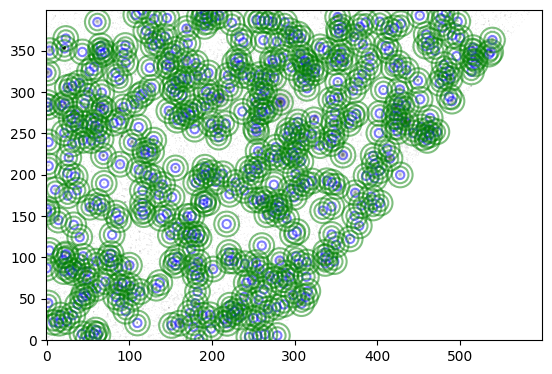

In [57]:
annulus_apert=CircularAnnulus(pos,r_in=10,r_out=15)
plt.figure()
plt.imshow(sec1,cmap='Greys',norm=LogNorm(),origin='lower')
aperture.plot(color='blue',lw=1.5,alpha=0.5);
annulus_apert.plot(color='green',lw=1.5,alpha=0.5);
plt.show()

In [58]:
#Performing Aperture Photometry
aperstats=ApertureStats(sec1,annulus_apert)
bkg_mean=aperstats.mean
apert_area=aperture.area_overlap(sec1)
total_bkg=bkg_mean*apert_area

star_data=aperture_photometry(sec1,aperture)

star_data['total_bkg']=total_bkg
for i in star_data.colnames:
    star_data[i].info.format='%.8g'
star_data.pprint()

 id  xcenter     ycenter    aperture_sum  total_bkg 
       pix         pix                              
--- --------- ------------- ------------ -----------
  1 50.447026 -0.0031392493    219.84117   19.804624
  2 184.41772     1.0683697    1676.9365   35.691336
  3 244.83157     3.4672697    80.239945   365.26889
  4 255.20238     5.0725017    1228.9345  -31.415927
  5 279.22674     5.2221588    41.664279   25.157285
  6 62.120754     6.0698624    26.324692   54.350747
  7 264.01394     6.6129931    271.56817   34.938668
  8 42.866453     7.2585342    71.964328   89.198791
  9 57.260679     7.9365596    85.334898   54.624578
...       ...           ...          ...         ...
462 184.88374     390.47579    44.416168   383.44355
463 203.32087      390.3555    87.287772   1092.2514
464 352.24509     390.45389    5296.9648   434.58698
465 209.40368     392.16362    1783.9729  -20.488648
466  451.5114     392.31172    293.72368  -15.422364
467 108.06537     393.13906    68.405926  -6.2

In [59]:
date='2013-08-31'
instrument='WFC'
filter='F435W'
q=acszpt.Query(date=date,detector=instrument)
zpt_table=q.fetch()
q_filter=acszpt.Query(date=date,detector=instrument,filt=filter)
filter_zpt=q_filter.fetch()
print(filter_zpt)



Filter PHOTLAM             PHOTFLAM            STmag  VEGAmag  ABmag 
       Angstrom erg / (Angstrom electron cm2) mag(ST)   mag   mag(AB)
------ -------- ----------------------------- ------- ------- -------
 F435W   4329.9                     3.181e-19  25.144  25.769  25.653


In [60]:
pt0= 25.653
extime=1662
mag=[]
for i in star_data:
    mag.append(pt0-(2.5*math.log10(abs(i[3]-i[4])/extime)))
star_data['Magnitude']=mag
star_data.pprint(max_lines=-1,max_width=-1)

 id   xcenter      ycenter     aperture_sum  total_bkg      Magnitude     
        pix          pix                                                  
--- ----------- ------------- ------------- ----------- ------------------
  1   50.447026 -0.0031392493     219.84117   19.804624 27.951804170285786
  2   184.41772     1.0683697     1676.9365   35.691336 25.666643919665038
  3   244.83157     3.4672697     80.239945   365.26889 27.567355125438002
  4   255.20238     5.0725017     1228.9345  -31.415927 25.953349245043757
  5   279.22674     5.2221588     41.664279   25.157285 30.660407562537923
  6   62.120754     6.0698624     26.324692   54.350747 30.085672612689542
  7   264.01394     6.6129931     271.56817   34.938668  27.76940532364377
  8   42.866453     7.2585342     71.964328   89.198791 30.613583108416464
  9   57.260679     7.9365596     85.334898   54.624578 29.986366686681713
 10   59.790514     11.837438     93.496873   28.579767 29.173679669942278
 11   199.06313     13.64